# iML1515 Evaluation

The goal of this notebook is to firstly evaluate iML1515, and see what transport reactions it facilitates, and what genes it has identified.\
The next step is to see what transporter genes the pipeline identify, and how the reactions these genes facilitate,differ and correspond with iML1515.

In [54]:
import json
import csv
import pandas as pd
import ast
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

In order to only retain what iML1515 has deems transport related reactions, one needs to look into the subsystems of the reactions. I have set the transport reactions to be defined by a single keyword: By simply containing "transport" in the subsystem name.

In [68]:
with open("iML1515.json", "r") as f:
    model = json.load(f)

def is_transport_subsystem(subsystem):
    return "transport" in subsystem.lower()


# Create mappings for gene IDs to names, metabolite IDs to names, and a set of all genes in the model
gene_map = {g["id"]: g.get("name", "Unknown") for g in model["genes"]}
gene_uniprot_map = {g["id"]: g.get("annotation", {}).get("uniprot", ["Unknown"]) for g in model["genes"]}
gene_ids_in_model = {g["id"] for g in model["genes"]}
metabolite_map = {m["id"]: m["name"] for m in model["metabolites"]}


# Store transport reactions and gene-tracking
transport_reactions = {}
all_genes = set()

# Iterate over all rxs in the model
for r in model["reactions"]:
    if "subsystem" in r and is_transport_subsystem(r["subsystem"]):
        metabolites = r.get("metabolites", {})

        # Extract gene IDsand UIDs
        gene_ids = r.get("gene_reaction_rule", "").split()
        gene_ids_clean = [g for g in gene_ids if g.strip("()") not in ["and", "or"]]
        genes = [gene_map.get(g.strip("()"), g.strip("()")) for g in gene_ids_clean if g.strip("()")]

        uniprot_ids = []
        for g in gene_ids_clean:
            g_clean = g.strip("()")
            if g_clean:
                uniprot_ids.extend(gene_uniprot_map.get(g_clean, ["Unknown"]))
        seen_uids = set()
        uniprot_ids = [x for x in uniprot_ids if not (x in seen_uids or seen_uids.add(x))]
        
        # Track all genes associated with the rx
        all_genes.update(genes)

        # Separate reactants and products for metabolite IDs
        reactants = [f"{-coef} {met}" for met, coef in metabolites.items() if coef < 0]
        products = [f"{coef} {met}" for met, coef in metabolites.items() if coef > 0]
        reaction_str = " + ".join(reactants) + " → " + " + ".join(products)

        # And metabolite names
        reactant_names = [f"{-coef} {metabolite_map.get(met, met)}" for met, coef in metabolites.items() if coef < 0]
        product_names = [f"{coef} {metabolite_map.get(met, met)}" for met, coef in metabolites.items() if coef > 0]
        reaction_str_names = " + ".join(reactant_names) + " → " + " + ".join(product_names)

        # Store details on rx
        transport_reactions[r["id"]] = {
            "name": r["name"],
            "subsystem": r.get("subsystem", "Unknown"),
            "reaction": reaction_str,
            "reaction_names": reaction_str_names,
            "genes": genes if genes else ["Unknown"],
            "uniprot_ids": uniprot_ids if uniprot_ids else ["Unknown"]
        }

print("Findings on transporters in iML1515\n")
print(f"Found {len(transport_reactions)} transport reactions.")
print(f"These reactions are coded for by {len(all_genes)} different genes in the model.")

for rid, data in transport_reactions.items():
    print(f"{rid}: {data['name']} (Subsystem: {data['subsystem']})")
    print(f"\t{data['reaction']}")
    print(f"\t{data['reaction_names']}")
    print(f"\tGenes: {', '.join(data['genes'])}")
    print(f"\tUniProt IDs: {', '.join(data['uniprot_ids'])}\n")


def save_tsv(fname):
    with open(fname, "w", newline="") as f:
        writer = csv.writer(f, delimiter="\t")
        writer.writerow(["Reaction ID", "Name", "Subsystem", "Reaction (IDs)", "Reaction (Names)", "Genes", "UIDs"])
        
        for rid, data in transport_reactions.items():
            writer.writerow([rid, data["name"], data["subsystem"], data["reaction"], data["reaction_names"], ", ".join(data["genes"]), ", ".join(data["uniprot_ids"])])

save_tsv("iML1515_transport_rxs.tsv")

Findings on transporters in iML1515

Found 817 transport reactions.
These reactions are coded for by 406 different genes in the model.
H2SO: Hydrogen sulfide oxidation (Subsystem: Inorganic Ion Transport and Metabolism)
	1.0 h2s_c + 2.0 o2_c → 2.0 h_c + 1.0 so4_c
	1.0 Hydrogen sulfide + 2.0 O2 O2 → 2.0 H+ + 1.0 Sulfate
	Genes: Unknown
	UniProt IDs: Unknown

26DAHtex: Meso-2,6-Diaminoheptanedioate transport via diffusion (extracellular to periplasm) (Subsystem: Transport, Outer Membrane Porin)
	1.0 26dap__M_e → 1.0 26dap__M_p
	1.0 Meso-2,6-Diaminoheptanedioate → 1.0 Meso-2,6-Diaminoheptanedioate
	Genes: phoE, ompF, ompN, ompC
	UniProt IDs: P02932, P02931, P77747, P06996

HCINNMtex: 3-hydroxycinnamic acid transport via diffusion (extracellular to periplasm) (Subsystem: Transport, Outer Membrane Porin)
	1.0 3hcinnm_e → 1.0 3hcinnm_p
	1.0 3-hydroxycinnamic acid → 1.0 3-hydroxycinnamic acid
	Genes: phoE, ompF, ompN, ompC
	UniProt IDs: P02932, P02931, P77747, P06996

HPPPNtex: 3-(3-hydroxyph

In [9]:
e_coli = pd.read_csv("e_coli_K12_MG1655_transporters_reactions.tsv", sep="\t")

In [ ]:
e_coli_uids = set(e_coli["QUID"])

1343

In [23]:
chebi_to_name = {}

for reaction_list in e_coli["Reaction"]:
    reaction_list = ast.literal_eval(reaction_list)

    for name, chebi in reaction_list:
        if chebi not in chebi_to_name and chebi != "no_reaction_identified":
            chebi_to_name[chebi] = name

len(chebi_to_name)

2216

In [63]:
model = pd.read_csv("iML1515_transport_rxs.tsv", sep="\t")
model_uids = set(model["UIDs"].str.split(", ").explode())
model_uids.remove("Unknown")
len(model_uids)

405

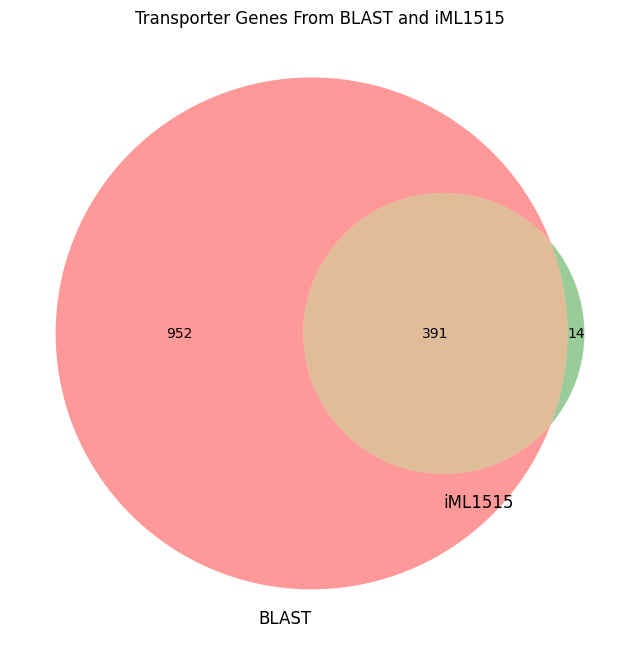

In [72]:
plt.figure(figsize=(8, 8))
venn2([e_coli_uids, model_uids], set_labels=("BLAST", "iML1515"))
plt.title("Transporter Genes From BLAST and iML1515")
plt.show()

In [70]:
only_model_uids = model_uids-e_coli_uids
only_model_uids
# Only P16683 was among the UIDs in the DB

{'P04982',
 'P0AB96',
 'P0ABD3',
 'P0AC59',
 'P0AEG6',
 'P13039',
 'P16683',
 'P16691',
 'P39405',
 'P69432',
 'P69490',
 'P77202',
 'P80645',
 'Q46871'}